Training model...

Epoch 01/8 | Train Loss: 0.6254 | Train Acc: 0.7740 | Test Loss: 0.4752 | Test Acc: 0.8292
Epoch 02/8 | Train Loss: 0.4064 | Train Acc: 0.8548 | Test Loss: 0.4079 | Test Acc: 0.8498
Epoch 03/8 | Train Loss: 0.3581 | Train Acc: 0.8702 | Test Loss: 0.3827 | Test Acc: 0.8605
Epoch 04/8 | Train Loss: 0.3287 | Train Acc: 0.8791 | Test Loss: 0.3743 | Test Acc: 0.8654
Epoch 05/8 | Train Loss: 0.3078 | Train Acc: 0.8871 | Test Loss: 0.3703 | Test Acc: 0.8660
Epoch 06/8 | Train Loss: 0.2907 | Train Acc: 0.8920 | Test Loss: 0.3460 | Test Acc: 0.8780
Epoch 07/8 | Train Loss: 0.2786 | Train Acc: 0.8964 | Test Loss: 0.3522 | Test Acc: 0.8748
Epoch 08/8 | Train Loss: 0.2702 | Train Acc: 0.8993 | Test Loss: 0.3342 | Test Acc: 0.8812


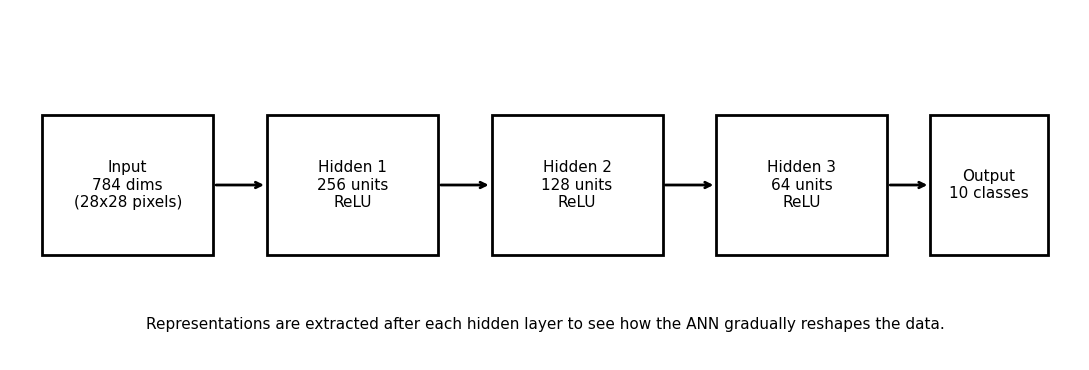

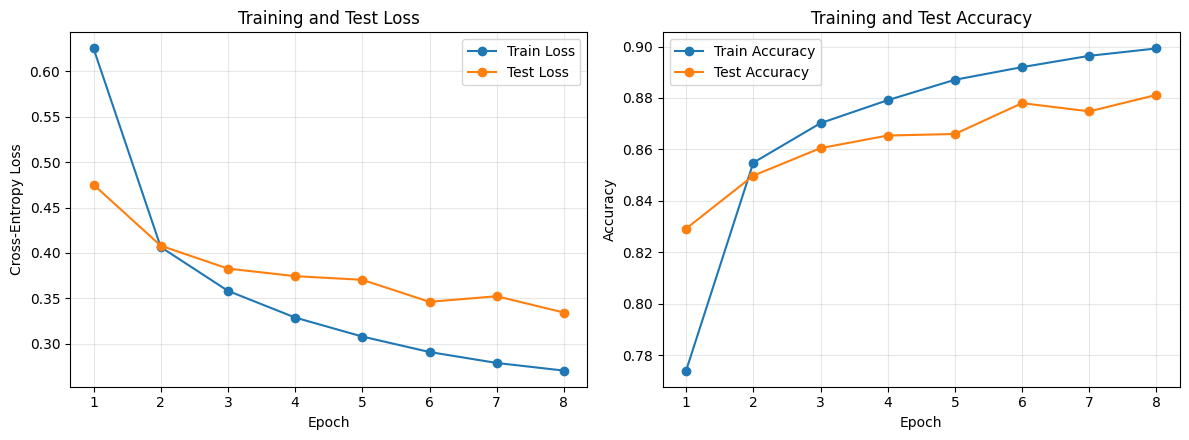

/tmp/ipykernel_1465/1510016859.py:476: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


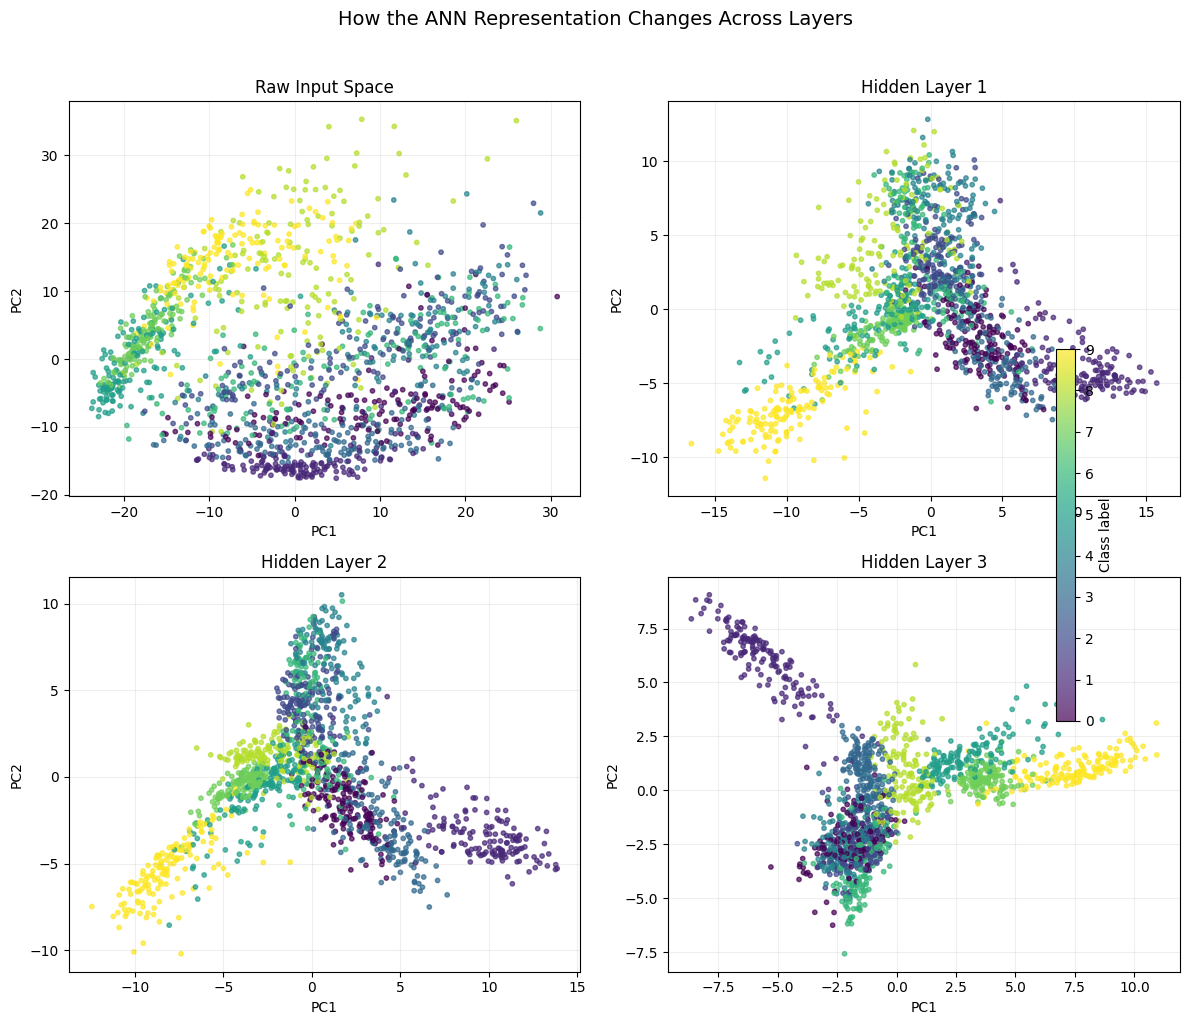


Computing layer-wise separability metrics...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Input    | Linear Probe Accuracy: 0.8040 | Silhouette Score: 0.0210


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Hidden 1 | Linear Probe Accuracy: 0.8725 | Silhouette Score: 0.1097


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Hidden 2 | Linear Probe Accuracy: 0.8875 | Silhouette Score: 0.2490


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Hidden 3 | Linear Probe Accuracy: 0.8865 | Silhouette Score: 0.3078


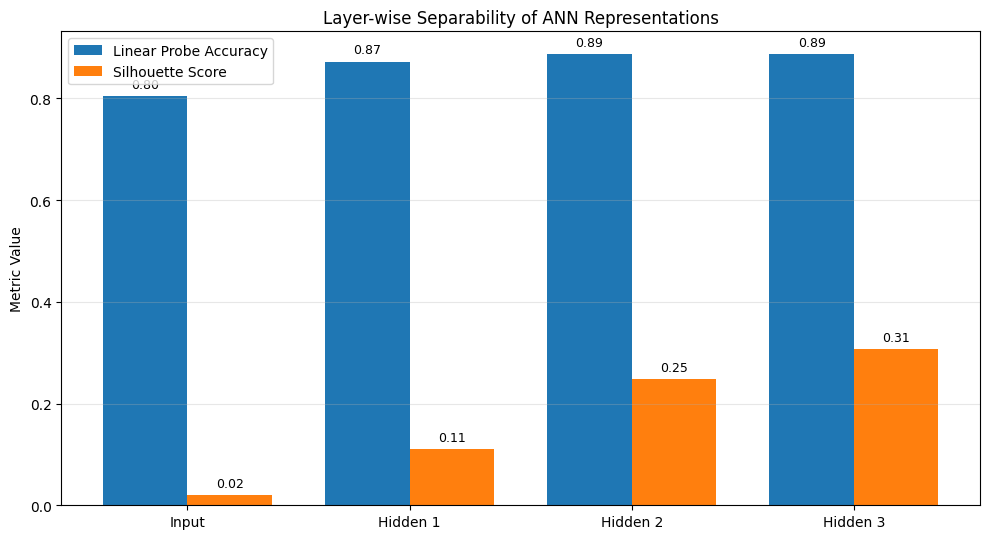


FINAL RESULTS SUMMARY
Final Test Accuracy of ANN: 0.8812

Layer-wise evidence for representation learning:
- Input    | Probe Accuracy = 0.8040 | Silhouette = 0.0210
- Hidden 1 | Probe Accuracy = 0.8725 | Silhouette = 0.1097
- Hidden 2 | Probe Accuracy = 0.8875 | Silhouette = 0.2490
- Hidden 3 | Probe Accuracy = 0.8865 | Silhouette = 0.3078

Interpretation:
1. The raw input space is usually harder to separate.
2. Hidden layers progressively transform the data.
3. If probe accuracy rises with depth, deeper layers are learning features
   that are easier for a simple classifier to use.
4. If the PCA plots show clearer structure deeper in the network, that gives
   qualitative evidence that the ANN is moving from raw pixels to abstraction.
5. The silhouette scores add a second quantitative check, so the tutorial does
   not rely only on visual impressions.

Saved figures:
- ./outputs/figure_1_architecture.png
- ./outputs/figure_2_training_curves.png
- ./outputs/figure_3_layerwise_pca.png

In [2]:
# ann_representation_tutorial.py
#
# Tutorial topic:
# "From Input to Abstraction: Tracking How an ANN Transforms Data Across Hidden Layers"
#
# What this script does:
# 1. Trains a simple ANN (MLP) on Fashion-MNIST
# 2. Extracts representations from each hidden layer
# 3. Visualises how the representation changes across layers
# 4. Measures whether deeper layers are easier to classify
# 5. Saves 4 teaching-friendly figures
#
# Output figures:
#   figure_1_architecture.png
#   figure_2_training_curves.png
#   figure_3_layerwise_pca.png
#   figure_4_separability_metrics.png
#
# Run:
#   python ann_representation_tutorial.py

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. Reproducibility and configuration
# ============================================================

@dataclass
class Config:
    # General
    seed: int = 42
    data_dir: str = "./data"
    output_dir: str = "./outputs"

    # Training
    batch_size: int = 128
    epochs: int = 8
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5

    # Representation analysis
    train_probe_samples: int = 5000
    test_probe_samples: int = 2000
    pca_plot_samples: int = 1500
    silhouette_samples: int = 1200

    # Plot control
    show_plots: bool = True

    # Hardware
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()


def set_seed(seed: int) -> None:
    """Make results reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
os.makedirs(CFG.output_dir, exist_ok=True)


# ============================================================
# 2. Dataset
# ============================================================

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(
    root=CFG.data_dir, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=CFG.data_dir, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)


# ============================================================
# 3. Model definition
# ============================================================

class MLP(nn.Module):
    """
    A small ANN with 3 hidden layers.

    We inspect the output of each hidden layer to see how
    the internal representation changes as depth increases.
    """
    def __init__(self, input_dim=784, hidden_dims=(256, 128, 64), num_classes=10):
        super().__init__()

        h1, h2, h3 = hidden_dims

        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.out = nn.Linear(h3, num_classes)

        self.act = nn.ReLU()

    def forward(self, x):
        """Standard forward pass returning only logits."""
        x = x.view(x.size(0), -1)

        z1 = self.act(self.fc1(x))
        z2 = self.act(self.fc2(z1))
        z3 = self.act(self.fc3(z2))
        logits = self.out(z3)

        return logits

    def forward_with_activations(self, x):
        """
        Forward pass that also returns internal representations.

        Returned representations:
        - input: flattened image
        - hidden1: activations after first hidden layer
        - hidden2: activations after second hidden layer
        - hidden3: activations after third hidden layer
        """
        x = x.view(x.size(0), -1)

        hidden1 = self.act(self.fc1(x))
        hidden2 = self.act(self.fc2(hidden1))
        hidden3 = self.act(self.fc3(hidden2))
        logits = self.out(hidden3)

        activations = {
            "input": x.detach(),
            "hidden1": hidden1.detach(),
            "hidden2": hidden2.detach(),
            "hidden3": hidden3.detach(),
        }

        return logits, activations


model = MLP().to(CFG.device)


# ============================================================
# 4. Training and evaluation
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay
)


def run_epoch(model, loader, optimizer=None):
    """
    Runs one pass through the data.

    If optimizer is provided -> training mode.
    Otherwise -> evaluation mode.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        if is_train:
            optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

print("Training model...\n")
for epoch in range(1, CFG.epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    test_loss, test_acc = run_epoch(model, test_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{CFG.epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )


# ============================================================
# 5. Figure 1: ANN architecture diagram
# ============================================================

def plot_architecture_diagram(output_path: str):
    """
    A simple teaching-oriented diagram showing:
    input -> hidden1 -> hidden2 -> hidden3 -> output

    This helps explain where representations are extracted.
    """
    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.axis("off")

    boxes = {
        "Input\n784 dims\n(28x28 pixels)": (0.03, 0.3, 0.16, 0.4),
        "Hidden 1\n256 units\nReLU": (0.24, 0.3, 0.16, 0.4),
        "Hidden 2\n128 units\nReLU": (0.45, 0.3, 0.16, 0.4),
        "Hidden 3\n64 units\nReLU": (0.66, 0.3, 0.16, 0.4),
        "Output\n10 classes": (0.86, 0.3, 0.11, 0.4),
    }

    for label, (x, y, w, h) in boxes.items():
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=11)

    arrow_y = 0.5
    arrow_pairs = [
        (0.19, 0.24),
        (0.40, 0.45),
        (0.61, 0.66),
        (0.82, 0.86),
    ]
    for x1, x2 in arrow_pairs:
        ax.annotate(
            "",
            xy=(x2, arrow_y),
            xytext=(x1, arrow_y),
            arrowprops=dict(arrowstyle="->", linewidth=2)
        )

    ax.text(
        0.5, 0.1,
        "Representations are extracted after each hidden layer to see how the ANN gradually reshapes the data.",
        ha="center", va="center", fontsize=11
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


plot_architecture_diagram(os.path.join(CFG.output_dir, "figure_1_architecture.png"))


# ============================================================
# 6. Figure 2: Training curves
# ============================================================

def plot_training_curves(history: dict, output_path: str):
    """
    Shows that the ANN learned the task reasonably well.
    This is useful context before analysing hidden representations.
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, history["test_loss"], marker="o", label="Test Loss")
    axes[0].set_title("Training and Test Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    axes[1].plot(epochs, history["test_acc"], marker="o", label="Test Accuracy")
    axes[1].set_title("Training and Test Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


plot_training_curves(
    history,
    os.path.join(CFG.output_dir, "figure_2_training_curves.png")
)


# ============================================================
# 7. Extract representations from each layer
# ============================================================

def sample_indices(dataset_size: int, n_samples: int, seed: int):
    """Returns a reproducible random subset of indices."""
    rng = np.random.default_rng(seed)
    return rng.choice(dataset_size, size=min(n_samples, dataset_size), replace=False)


def make_subset_loader(dataset, n_samples: int, batch_size: int, seed: int):
    """Creates a DataLoader over a random subset."""
    idx = sample_indices(len(dataset), n_samples, seed)
    subset = Subset(dataset, idx)
    return DataLoader(subset, batch_size=batch_size, shuffle=False)


def collect_representations(model, loader):
    """
    Collects input and hidden-layer activations for all examples in a loader.
    Returns:
        reps: dict[layer_name -> np.ndarray]
        labels: np.ndarray
    """
    model.eval()

    all_reps = {
        "input": [],
        "hidden1": [],
        "hidden2": [],
        "hidden3": [],
    }
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(CFG.device)
            logits, activations = model.forward_with_activations(images)

            for key in all_reps:
                all_reps[key].append(activations[key].cpu().numpy())

            all_labels.append(labels.numpy())

    for key in all_reps:
        all_reps[key] = np.concatenate(all_reps[key], axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    return all_reps, all_labels


train_probe_loader = make_subset_loader(
    train_dataset, CFG.train_probe_samples, CFG.batch_size, seed=CFG.seed
)
test_probe_loader = make_subset_loader(
    test_dataset,
    max(CFG.test_probe_samples, CFG.pca_plot_samples, CFG.silhouette_samples),
    CFG.batch_size,
    seed=CFG.seed + 1
)

train_reps, train_labels = collect_representations(model, train_probe_loader)
test_reps, test_labels = collect_representations(model, test_probe_loader)


# ============================================================
# 8. Figure 3: PCA visualisation across layers
# ============================================================

def pca_project(X: np.ndarray, n_components: int = 2) -> np.ndarray:
    """
    PCA projection to 2D for visualisation.
    Standardisation is used so dimensions with larger magnitude
    do not dominate the PCA projection.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, random_state=CFG.seed)
    return pca.fit_transform(X_scaled)


def plot_layerwise_pca(reps: dict, labels: np.ndarray, output_path: str, max_points: int = 1500):
    """
    Creates a 2x2 grid:
    - raw input
    - hidden1
    - hidden2
    - hidden3

    Teaching purpose:
    show how class structure becomes clearer deeper in the network.
    """
    n = min(max_points, len(labels))
    X_labels = labels[:n]

    layer_order = ["input", "hidden1", "hidden2", "hidden3"]
    titles = {
        "input": "Raw Input Space",
        "hidden1": "Hidden Layer 1",
        "hidden2": "Hidden Layer 2",
        "hidden3": "Hidden Layer 3",
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for ax, layer_name in zip(axes, layer_order):
        X = reps[layer_name][:n]
        X_2d = pca_project(X)

        scatter = ax.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=X_labels,
            s=10,
            alpha=0.7
        )
        ax.set_title(titles[layer_name])
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True, alpha=0.2)

    cbar = fig.colorbar(scatter, ax=axes.tolist(), fraction=0.02, pad=0.02)
    cbar.set_label("Class label")

    plt.suptitle("How the ANN Representation Changes Across Layers", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


plot_layerwise_pca(
    test_reps,
    test_labels,
    os.path.join(CFG.output_dir, "figure_3_layerwise_pca.png"),
    max_points=CFG.pca_plot_samples
)


# ============================================================
# 9. Figure 4: Quantitative separability metrics
# ============================================================

def compute_linear_probe_accuracy(train_X, train_y, test_X, test_y):
    """
    Linear probe:
    Train a simple logistic regression classifier on frozen representations.

    If a deeper layer is easier to classify with a simple linear model,
    that suggests the ANN has learned a more separable representation.
    """
    scaler = StandardScaler()
    train_X_scaled = scaler.fit_transform(train_X)
    test_X_scaled = scaler.transform(test_X)

    clf = LogisticRegression(
        max_iter=1000,
        multi_class="auto",
        solver="lbfgs",
        random_state=CFG.seed
    )
    clf.fit(train_X_scaled, train_y)
    preds = clf.predict(test_X_scaled)
    return accuracy_score(test_y, preds)


def compute_silhouette(X, y, max_samples: int = 1200):
    """
    Computes silhouette score on a subset.
    Higher is generally better separated.

    This complements the visual story, but does not replace interpretation.
    """
    n = min(max_samples, len(y))
    X = X[:n]
    y = y[:n]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return silhouette_score(X_scaled, y)


layer_order = ["input", "hidden1", "hidden2", "hidden3"]
layer_titles = ["Input", "Hidden 1", "Hidden 2", "Hidden 3"]

probe_accuracies = []
silhouette_scores = []

print("\nComputing layer-wise separability metrics...\n")
for layer_name, layer_title in zip(layer_order, layer_titles):
    acc = compute_linear_probe_accuracy(
        train_reps[layer_name], train_labels,
        test_reps[layer_name][:CFG.test_probe_samples],
        test_labels[:CFG.test_probe_samples]
    )
    sil = compute_silhouette(
        test_reps[layer_name],
        test_labels,
        max_samples=CFG.silhouette_samples
    )

    probe_accuracies.append(acc)
    silhouette_scores.append(sil)

    print(
        f"{layer_title:8s} | "
        f"Linear Probe Accuracy: {acc:.4f} | "
        f"Silhouette Score: {sil:.4f}"
    )


def plot_separability_metrics(layer_titles, probe_accuracies, silhouette_scores, output_path: str):
    """
    Shows two quantitative measures:
    1. Linear probe accuracy
    2. Silhouette score

    Together, these support the tutorial claim that deeper representations
    become more useful and more structured.
    """
    x = np.arange(len(layer_titles))
    width = 0.38

    fig, ax1 = plt.subplots(figsize=(10, 5.5))

    bars1 = ax1.bar(x - width / 2, probe_accuracies, width, label="Linear Probe Accuracy")
    bars2 = ax1.bar(x + width / 2, silhouette_scores, width, label="Silhouette Score")

    ax1.set_xticks(x)
    ax1.set_xticklabels(layer_titles)
    ax1.set_ylabel("Metric Value")
    ax1.set_title("Layer-wise Separability of ANN Representations")
    ax1.legend()
    ax1.grid(True, axis="y", alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if CFG.show_plots:
        plt.show()
    plt.close(fig)


plot_separability_metrics(
    layer_titles,
    probe_accuracies,
    silhouette_scores,
    os.path.join(CFG.output_dir, "figure_4_separability_metrics.png")
)


# ============================================================
# 10. Final summary for the tutorial
# ============================================================

final_test_acc = history["test_acc"][-1]

print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"Final Test Accuracy of ANN: {final_test_acc:.4f}\n")

print("Layer-wise evidence for representation learning:")
for title, acc, sil in zip(layer_titles, probe_accuracies, silhouette_scores):
    print(f"- {title:8s} | Probe Accuracy = {acc:.4f} | Silhouette = {sil:.4f}")

print("\nInterpretation:")
print("1. The raw input space is usually harder to separate.")
print("2. Hidden layers progressively transform the data.")
print("3. If probe accuracy rises with depth, deeper layers are learning features")
print("   that are easier for a simple classifier to use.")
print("4. If the PCA plots show clearer structure deeper in the network, that gives")
print("   qualitative evidence that the ANN is moving from raw pixels to abstraction.")
print("5. The silhouette scores add a second quantitative check, so the tutorial does")
print("   not rely only on visual impressions.")

print("\nSaved figures:")
print(f"- {os.path.join(CFG.output_dir, 'figure_1_architecture.png')}")
print(f"- {os.path.join(CFG.output_dir, 'figure_2_training_curves.png')}")
print(f"- {os.path.join(CFG.output_dir, 'figure_3_layerwise_pca.png')}")
print(f"- {os.path.join(CFG.output_dir, 'figure_4_separability_metrics.png')}")
print("=" * 70)